This model will be used to estimate mass based on just the overhead RGB images. It has been proven that we can find better performance for the carbohydrate estimation if mass is given the model. This will later be combined with the DINOv2 overhead RGB branch with a fusion head to predict carbohydrates.

In [ ]:
!pip install -q pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Loading metadata

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows:", len(df))

           dish_id  total_mass  total_carb split source_cafe
0  dish_1556575327       152.0      10.618  test       cafe1
1  dish_1557861216         1.0       0.000  test       cafe1
2  dish_1557862345        63.0       0.000  test       cafe1
3  dish_1557862696        77.0       3.850  test       cafe1
4  dish_1557862738       118.0       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows: 3262


Loading dataset

In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


Splitting dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Later test added to determine the average mass of a dish in the test set.

In [ ]:
mean_test_mass = test_df["total_mass"].mean()
mae_test_mass = 27.8252
rmse_test_mass = 44.0948

print(f"Mean test mass: {mean_test_mass:.2f} g")
print(f"MAE as % of mean test mass: {(mae_test_mass / mean_test_mass) * 100:.2f}%")
print(f"RMSE as % of mean test mass: {(rmse_test_mass / mean_test_mass) * 100:.2f}%")

Mean test mass: 198.51 g
MAE as % of mean test mass: 14.02%
RMSE as % of mean test mass: 22.21%


Saving RGB paths to csv

In [ ]:
train_csv = PREP_DIR / "train_rgb_only_mass.csv"
val_csv   = PREP_DIR / "val_rgb_only_mass.csv"
test_csv  = PREP_DIR / "test_rgb_only_mass.csv"
full_csv  = PREP_DIR / "full_filtered_rgb_only_mass.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/prep_files/train_rgb_only_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/prep_files/val_rgb_only_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/prep_files/test_rgb_only_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/prep_files/full_filtered_rgb_only_mass.csv


SWITCH TO GPU FOR MODEL TRAINING

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from huggingface_hub import notebook_login, HfApi

Configuration

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224 #Even though it is not the best image size for DINOv3 it was determined to use 224x224 img size in order to fit better with the carbohydrate branch.
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

# ---------------------------------------------------------
# DINOv3 options:
#   "dinov3_vit_small_lvd1689m"
#   "dinov3_vit_small_plus_lvd1689m"
#   "dinov3_vit_base_lvd1689m"
#   "dinov3_vit_large_lvd1689m"
# ---------------------------------------------------------
BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_rgb_only_mass.csv"
val_csv   = PREP_DIR / "val_rgb_only_mass.csv"
test_csv  = PREP_DIR / "test_rgb_only_mass.csv"

Loading dataset

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2421
Val:   334
Test:  507


,dish_id,total_mass,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,36.0,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,23.0,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,62.0,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,64.0,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,28.0,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe["total_mass"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16,)


Showing a sample

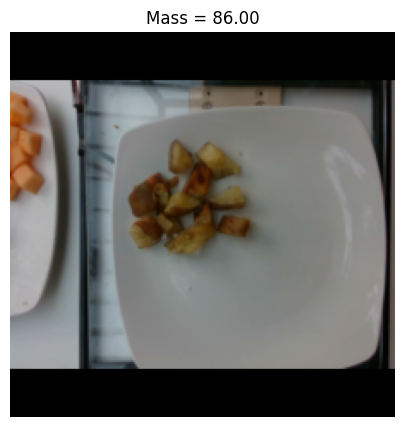

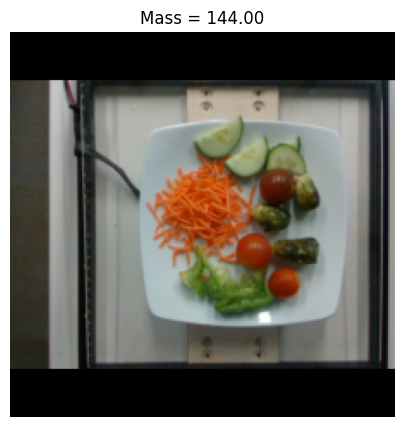

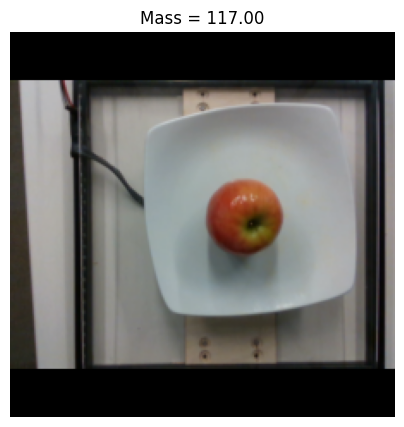

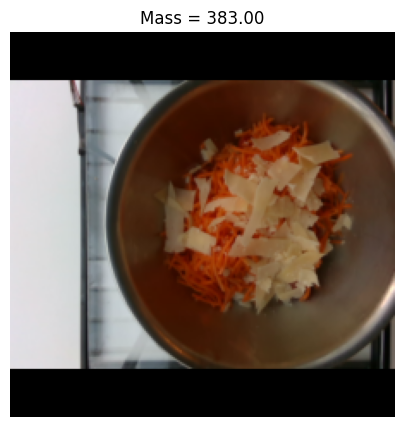

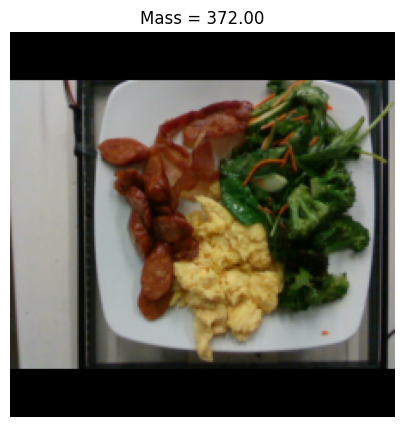

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(5):
    sample_img = batch_inputs["rgb_input"][0].numpy().astype("uint8")
    sample_label = batch_labels[0].numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Mass = {sample_label:.2f}")
    plt.axis("off")
    plt.show()

Loading image converter and backbone

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False

print("Using preset:", BACKBONE_PRESET)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))

Using preset: dinov3_vit_base_lvd1689m
Image size: (224, 224)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Model architecture

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = image_converter(rgb_input)
x = backbone(x)
x = extract_backbone_tensor(x)

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
output = layers.Dense(1, activation="linear", name="mass_output")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dinov3_mass_regressor"
)

model.summary()

Model: "rgb_only_dinov3_mass_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV3ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_backbone                 │ (None, 201, 768)       │    85,660,416 │
│ (DINOV3Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 201, 768)       │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,875,329 (327.59 MB)

 Trainable params: 214,913 (839.50 KB)

 Non-trainable params: 85,660,416 (326.77 MB)

Stage 1 training (Backbone frozen)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 60512.3734 - mae: 187.8949 - mse: 60512.3734
Epoch 1: val_loss improved from None to 20849.40234, saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - loss: 49228.4609 - mae: 160.6873 - mse: 49228.4609 - val_loss: 20849.4023 - val_mae: 116.6451 - val_mse: 20849.4023 - learning_rate: 2.0000e-04
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 21162.4074 - mae: 112.7814 - mse: 21162.4074
Epoch 2: val_loss improved from 20849.40234 to 14414.29199, saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage1.weights.h5
152/1

Stage 1 evaluation on test set

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 mass test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 2753.0244 - mae: 36.8627 - mse: 2753.0244
Stage 1 mass test results:
loss: 2753.0244
mae: 36.8627
mse: 2753.0244


Stage 2 (unfreezing 30%)

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")

trainable_count = 0
frozen_count = 0
for layer in backbone.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        frozen_count += 1

print("Backbone trainable layers:", trainable_count)
print("Backbone frozen layers:   ", frozen_count)

Total backbone layers: 5
Frozen layers:         3
Trainable layers:      2
Backbone trainable layers: 2
Backbone frozen layers:    3


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 2884.4780 - mae: 37.1098 - mse: 2884.4780
Epoch 1: val_loss improved from None to 4018.49170, saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 95s 384ms/step - loss: 5778.2095 - mae: 38.5263 - mse: 5778.2095 - val_loss: 4018.4917 - val_mae: 42.5252 - val_mse: 4018.4917 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 2932.9677 - mae: 35.1054 - mse: 2932.9677
Epoch 2: val_loss improved from 4018.49170 to 2833.18774, saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass/best_model_stage2.weights.h5
15

Evaluation on test set

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 mass test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 1944.3549 - mae: 27.8252 - mse: 1944.3549
Stage 2 mass test results:
loss: 1944.3549
mae: 27.8252
mse: 1944.3549


Plotting training and validation curves

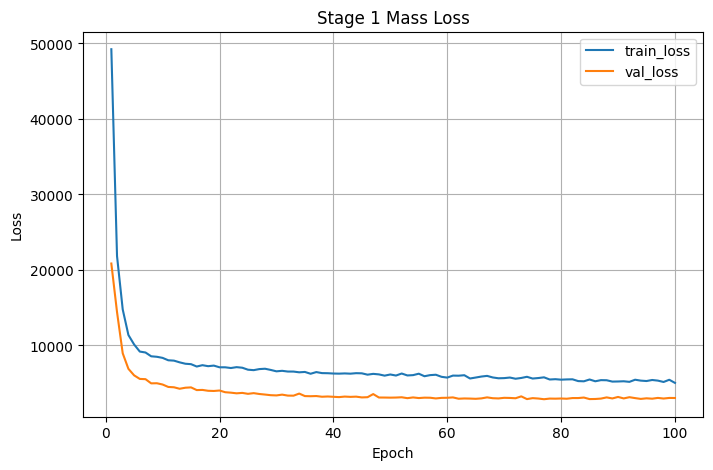

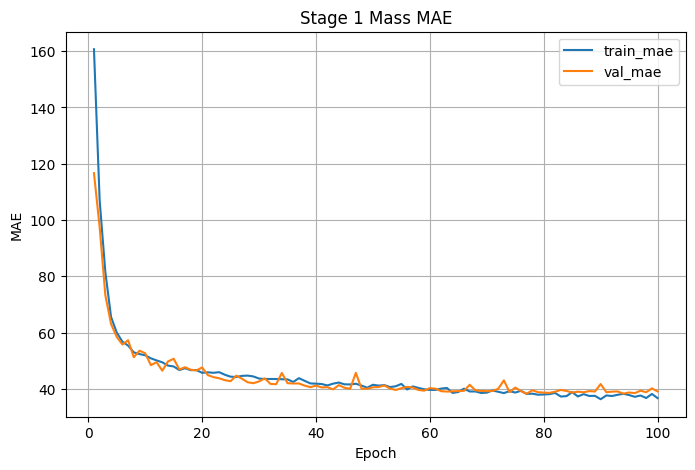

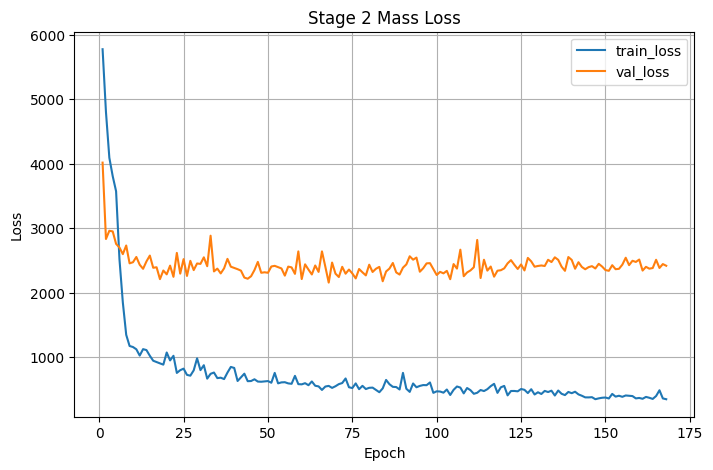

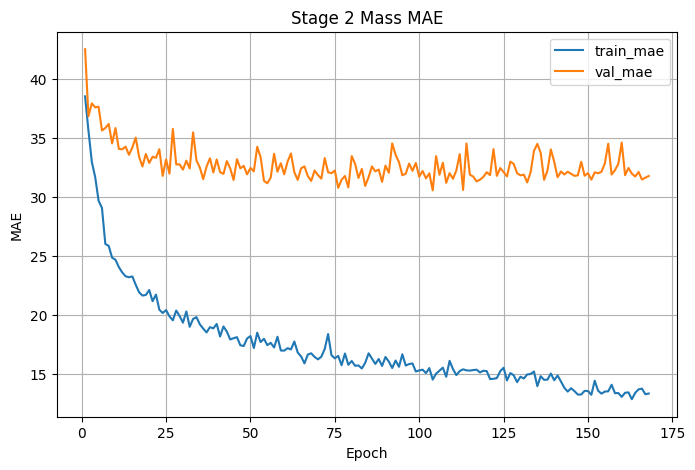

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_stage1, "Stage 1 Mass")
plot_history(history_stage2, "Stage 2 Mass")

Comparing stage 1 and stage 2 performance

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison_mass.csv", index=False)

,stage,test_loss,test_mae,test_mse
0,stage_1,2753.024414,36.862698,2753.024414
1,stage_2,1944.354858,27.825171,1944.354858
